# EDA — Bundesliga shots, goals and ELO (2016/17–2025/26)

Exploration of the raw data behind the two momentum hypotheses:

1. Does a team show a measurable improvement in attacking performance after an **equalising goal**?
2. Is the equalising team **more likely to score the next goal**, beyond what team quality predicts?

This notebook is descriptive only — no modelling, no inference. Its job is to
check the data supports the analysis and to show the raw patterns the R
analysis will formally test.

In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))
from config import DATA_RAW_DIR

# -- project color theme (mirrors config.R — keep the two in sync) -----------
COL_EQ      = "#1F3A93"   # equalising team — deep blue
COL_OPP     = "#C0392B"   # opponent — warm red
COL_NEUTRAL = "#2C3E50"   # structure / neutral text
COL_BG      = "#FAF6F1"   # cream background
COL_GRID    = "#D8D2C7"   # grid lines
COL_GREY    = "#AAAAAA"   # no-goal / neutral category

plt.rcParams.update({
    "figure.facecolor": COL_BG, "axes.facecolor": COL_BG,
    "axes.edgecolor": COL_GRID, "axes.labelcolor": COL_NEUTRAL,
    "axes.grid": True, "grid.color": COL_GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": COL_NEUTRAL, "ytick.color": COL_NEUTRAL,
    "text.color": COL_NEUTRAL, "font.size": 11, "figure.dpi": 110,
    "savefig.facecolor": COL_BG,
})

shots = pd.read_csv(os.path.join(DATA_RAW_DIR, "shots_raw.csv"))
meta  = pd.read_csv(os.path.join(DATA_RAW_DIR, "match_metadata.csv"))
melo  = pd.read_csv(os.path.join(DATA_RAW_DIR, "match_elo.csv"))
print(f"shots: {shots.shape} | matches: {meta.shape} | match_elo: {melo.shape}")

shots: (79723, 22) | matches: (3059, 8) | match_elo: (3059, 13)


## 1. Dataset overview

In [2]:
shots.head(3)

,shot_id,match_id,season,date,home_team,away_team,home_goals_final,away_goals_final,team,side,...,result,situation,shot_type,last_action,x,y,player,player_id,player_assisted,own_goal
0,127429,1327,2016,2016-08-26 22:30:00,Bayern Munich,Werder Bremen,6,0,Bayern Munich,h,...,BlockedShot,OpenPlay,RightFoot,Pass,0.873,0.472,Thomas Müller,224,Philipp Lahm,False
1,127430,1327,2016,2016-08-26 22:30:00,Bayern Munich,Werder Bremen,6,0,Bayern Munich,h,...,Goal,OpenPlay,RightFoot,NaN,0.719,0.472,Xabi Alonso,230,NaN,False
2,127432,1327,2016,2016-08-26 22:30:00,Bayern Munich,Werder Bremen,6,0,Bayern Munich,h,...,SavedShot,OpenPlay,RightFoot,Pass,0.910,0.427,Thomas Müller,224,Philipp Lahm,False


In [3]:
overview = meta.groupby("season").size().rename("matches").to_frame()
overview["shots"] = shots.groupby("season").size()
overview["shots_per_match"] = (overview["shots"] / overview["matches"]).round(1)
overview["goals"] = shots[shots.result.isin(["Goal", "OwnGoal"])].groupby("season").size()
overview["goals_per_match"] = (overview["goals"] / overview["matches"]).round(2)
overview

,matches,shots,shots_per_match,goals,goals_per_match
season,,,,,
2016,306,7646,25.0,877,2.87
2017,306,7737,25.3,855,2.79
2018,306,8264,27.0,973,3.18
2019,306,8148,26.6,982,3.21
2020,306,7590,24.8,928,3.03
2021,306,7949,26.0,954,3.12
2022,306,7815,25.5,971,3.17
2023,306,8506,27.8,985,3.22
2024,305,7944,26.0,955,3.13


Season 2024/25 has 305 matches, not 306: **Holstein Kiel vs Bochum
(Dec 2024)** was abandoned (Bochum's keeper hit by a lighter) and later awarded
2–0 by the DFB court. Understat carries no shot data for it, so it is absent —
correctly — from the whole pipeline.

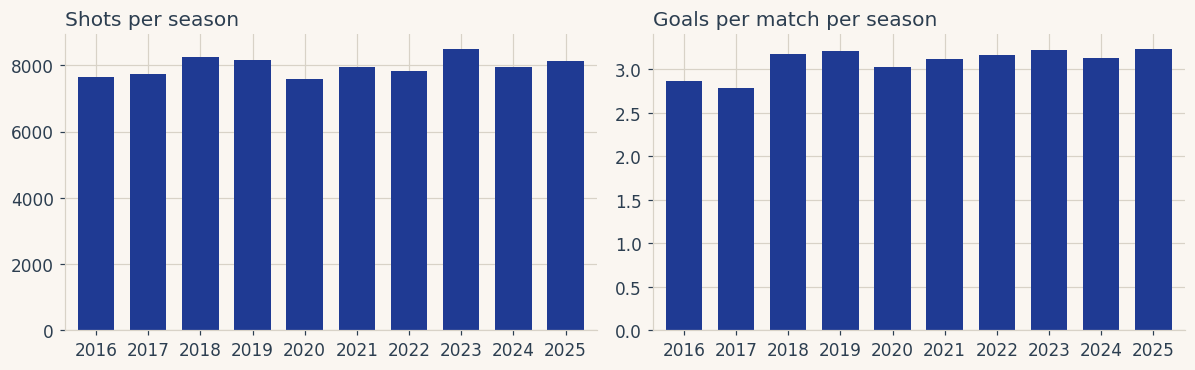

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
overview["shots"].plot.bar(ax=axes[0], color=COL_EQ, width=0.7)
axes[0].set_title("Shots per season", loc="left", color=COL_NEUTRAL)
overview["goals_per_match"].plot.bar(ax=axes[1], color=COL_EQ, width=0.7)
axes[1].set_title("Goals per match per season", loc="left", color=COL_NEUTRAL)
for ax in axes:
    ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0)
plt.tight_layout()

## 2. Feature checks

`result` values, missingness, and the fields the analysis depends on
(`minute`, `xg`, coordinates).

In [5]:
print("result values:")
print(shots.result.value_counts().to_string())
print("\nsituation values:")
print(shots.situation.value_counts().to_string())
print("\nmissing values per column:")
print(shots.isna().sum()[lambda s: s > 0].to_string() if shots.isna().any().any() else "  none in key columns")

result values:
result
MissedShots    29870
BlockedShot    20164
SavedShot      18653
Goal            9235
ShotOnPost      1566
OwnGoal          235

situation values:
situation
OpenPlay          57969
FromCorner        12530
SetPiece           5570
DirectFreekick     2703
Penalty             951

missing values per column:
last_action         9881
player_assisted    21041


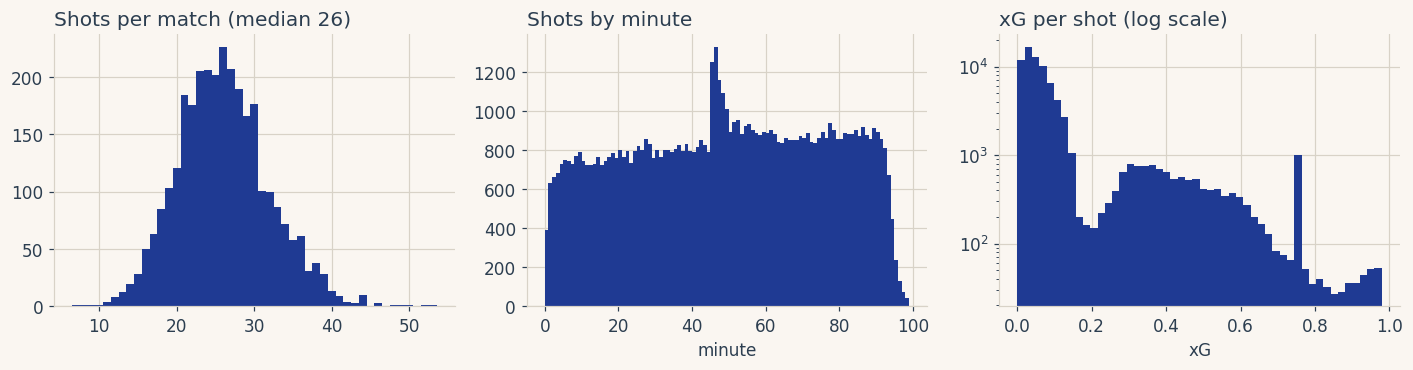

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

spm = shots.groupby("match_id").size()
axes[0].hist(spm, bins=np.arange(spm.min(), spm.max() + 2) - 0.5, color=COL_EQ)
axes[0].set_title(f"Shots per match (median {spm.median():.0f})", loc="left", color=COL_NEUTRAL)

axes[1].hist(shots.minute, bins=np.arange(0, 100, 1), color=COL_EQ)
axes[1].set_title("Shots by minute", loc="left", color=COL_NEUTRAL)
axes[1].set_xlabel("minute")

axes[2].hist(shots.xg, bins=50, color=COL_EQ)
axes[2].set_yscale("log")
axes[2].set_title("xG per shot (log scale)", loc="left", color=COL_NEUTRAL)
axes[2].set_xlabel("xG")
plt.tight_layout()

Spikes at minutes 45 and 90 are stoppage time (Understat clips added time
into the last regular minute). The xG distribution is heavily right-skewed, as
expected — most shots are low-quality chances.

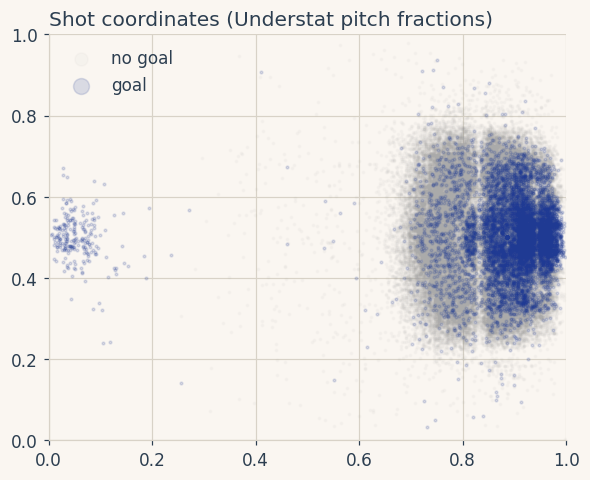

In [7]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
goals_mask = shots.result.isin(["Goal", "OwnGoal"])
ax.scatter(shots.loc[~goals_mask, "x"], shots.loc[~goals_mask, "y"],
           s=2, alpha=0.05, color=COL_GREY, label="no goal")
ax.scatter(shots.loc[goals_mask, "x"], shots.loc[goals_mask, "y"],
           s=3, alpha=0.15, color=COL_EQ, label="goal")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title("Shot coordinates (Understat pitch fractions)", loc="left", color=COL_NEUTRAL)
leg = ax.legend(markerscale=6, framealpha=0)
plt.tight_layout()

## 3. ELO coverage and balance

The second hypothesis controls for team quality via ClubElo ratings, so
coverage and the distribution of the pre-match ELO difference matter.

ELO coverage by season (%):
season
2016    100.0
2017    100.0
2018    100.0
2019    100.0
2020    100.0
2021    100.0
2022    100.0
2023    100.0
2024    100.0
2025    100.0

Overall: 100.0%


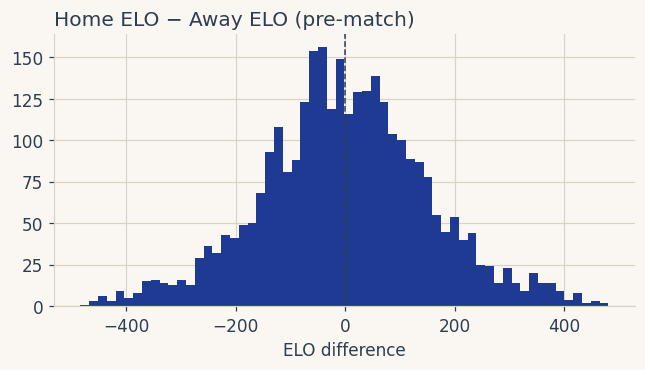

In [8]:
cov = melo.groupby("season")["elo_difference"].apply(lambda s: s.notna().mean() * 100)
print("ELO coverage by season (%):")
print(cov.round(1).to_string())
print(f"\nOverall: {melo.elo_difference.notna().mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(melo.elo_difference.dropna(), bins=60, color=COL_EQ)
ax.axvline(0, color=COL_NEUTRAL, linewidth=1, linestyle="--")
ax.set_title("Home ELO − Away ELO (pre-match)", loc="left", color=COL_NEUTRAL)
ax.set_xlabel("ELO difference")
plt.tight_layout()

## 4. Hypothesis-oriented EDA: equalisers

Reconstruct the goal sequence of every match. The scoring team of a `Goal` row
is the shot's team; an `OwnGoal` row is recorded under the team that concedes,
so the goal credits the **opponent** (verified against final scores: 100% of
matches reconcile under this convention).

An **equaliser** is a goal that brings the trailing team level.

In [9]:
goals = shots[shots.result.isin(["Goal", "OwnGoal"])].copy()
opponent = np.where(goals.side == "h", goals.away_team, goals.home_team)
goals["scoring_team"] = np.where(goals.result == "Goal", goals.team, opponent)

# order goals within each match (shot_id breaks ties within the same minute)
goals = goals.sort_values(["match_id", "minute", "shot_id"]).reset_index(drop=True)

def label_goals(g):
    h = a = 0
    rows = []
    for _, r in g.iterrows():
        scored_by_home = r.scoring_team == r.home_team
        before = (h, a)
        h, a = (h + 1, a) if scored_by_home else (h, a + 1)
        # equaliser: scoring team was exactly one behind before this goal
        trailing_by_one = (before[0] - before[1] == -1) if scored_by_home else (before[1] - before[0] == -1)
        rows.append({"equaliser": trailing_by_one, "score_h_after": h, "score_a_after": a})
    return pd.DataFrame(rows, index=g.index)

goals = pd.concat([goals, goals.groupby("match_id", group_keys=False).apply(label_goals)], axis=1)
goals["goal_seq"] = goals.groupby("match_id").cumcount() + 1

n_eq = goals.equaliser.sum()
n_matches_with_eq = goals[goals.equaliser].match_id.nunique()
print(f"Equalising goals: {n_eq:,}  in {n_matches_with_eq:,} matches "
      f"({n_matches_with_eq / meta.match_id.nunique() * 100:.1f}% of matches)")

Equalising goals: 1,594  in 1,312 matches (42.9% of matches)


C:\Users\sumiy\AppData\Local\Temp\ipykernel_16552\581130479.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  goals = pd.concat([goals, goals.groupby("match_id", group_keys=False).apply(label_goals)], axis=1)


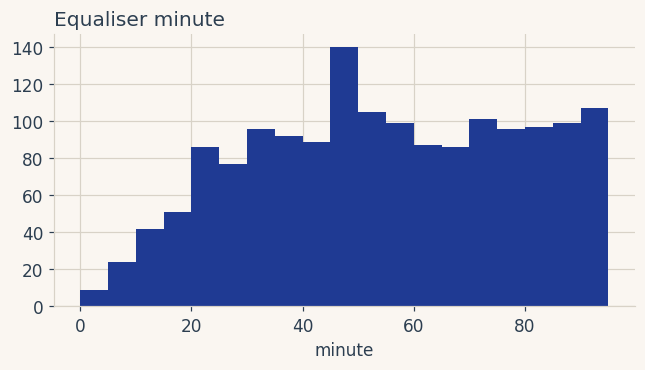

In [10]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(goals.loc[goals.equaliser, "minute"], bins=np.arange(0, 100, 5), color=COL_EQ)
ax.set_title("Equaliser minute", loc="left", color=COL_NEUTRAL)
ax.set_xlabel("minute")
plt.tight_layout()

### Who scores the next goal after an equaliser?

Raw descriptive split — no quality adjustment yet (that is exactly what the R
analysis will add). Each equaliser is one observation; the outcome is whether
the next goal in the match falls to the equalising team, the opponent, or
nobody.

next_goal
no further goal    595
equalising team    502
opponent           497


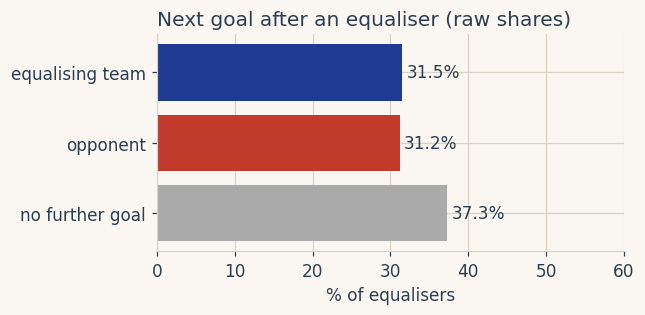

In [11]:
eq = goals[goals.equaliser].copy()
nxt = []
for _, r in eq.iterrows():
    later = goals[(goals.match_id == r.match_id) & (goals.goal_seq == r.goal_seq + 1)]
    if later.empty:
        nxt.append("no further goal")
    elif later.iloc[0].scoring_team == r.scoring_team:
        nxt.append("equalising team")
    else:
        nxt.append("opponent")
eq["next_goal"] = nxt

share = eq.next_goal.value_counts(normalize=True).reindex(
    ["equalising team", "opponent", "no further goal"])
print(eq.next_goal.value_counts().to_string())

fig, ax = plt.subplots(figsize=(6, 3))
colors = [COL_EQ, COL_OPP, COL_GREY]
ax.barh(share.index[::-1], share[::-1] * 100, color=colors[::-1])
for i, v in enumerate(share[::-1] * 100):
    ax.text(v + 0.6, i, f"{v:.1f}%", va="center", color=COL_NEUTRAL)
ax.set_xlim(0, 60)
ax.set_title("Next goal after an equaliser (raw shares)", loc="left", color=COL_NEUTRAL)
ax.set_xlabel("% of equalisers")
plt.tight_layout()

### Attacking output around the equaliser

Average xG per 15 minutes for the equalising team, in the windows before and
after its equaliser (within the same match, minutes 0–90 only). Purely
descriptive — selection effects (game state, opponent pushing) are untouched
here and belong to the formal analysis.

In [12]:
windows = []
for _, r in eq.iterrows():
    m = shots[shots.match_id == r.match_id]
    # own shots of the equalising team, excluding the equalising shot itself
    team_shots = m[(m.team == r.scoring_team) & (m.shot_id != r.shot_id)]
    for label, lo, hi in [("before", r.minute - 15, r.minute), ("after", r.minute, r.minute + 15)]:
        if lo < 0 or hi > 90:
            continue
        w = team_shots[(team_shots.minute >= lo) & (team_shots.minute < hi)]
        windows.append({"window": label, "xg": w.xg.sum(), "n_shots": len(w)})
win = pd.DataFrame(windows)
summary = win.groupby("window")[["xg", "n_shots"]].mean().reindex(["before", "after"]).round(3)
print("Mean per 15-minute window (equalising team):")
summary

Mean per 15-minute window (equalising team):


,xg,n_shots
window,,
before,0.194,2.17
after,0.245,2.19


## 5. Takeaways for the analysis

- All 10 seasons present; one legitimately missing match (awarded, not played
  to a finish) — document, don't impute.
- `OwnGoal` rows sit under the conceding team; goal credit goes to the
  opponent. The equaliser filter must use this convention (verified 100%).
- Coordinates are clean fractions in [0,1]; minutes include stoppage clipped
  to 45/90 — time-window analyses should treat 45 and 90 as right-censored
  bins, not exact timestamps.
- ELO coverage is high and the difference distribution is roughly symmetric —
  usable as the team-quality control in hypothesis 2.
- The raw next-goal split and the before/after xG comparison are the
  descriptive versions of hypotheses 2 and 1 respectively; both need quality
  and game-state adjustment before any conclusion, which is the job of the R
  analysis. **A null result is a valid outcome.**